<a href="https://colab.research.google.com/github/linneverh/Sust-Finance/blob/Assignment-2/copy_van_Assignment_2_Q3_postcleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment: ESG Score**

In [49]:
# Import packages

# installing PyPortfolioOpt
!pip install pyportfolioopt
!pip install cvxpy

# installing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import yfinance as yf
import scipy.optimize as sco
import scipy.interpolate as sci
import matplotlib.pyplot as plt
import cvxpy as cp
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from datetime import datetime, timedelta
from scipy.optimize import minimize
from pypfopt.objective_functions import portfolio_return
from tqdm import tqdm

In [50]:
#import dataset from git
url_DS_ESGScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_ESGScore_Y.csv'
DS_ESGScore_Y = pd.read_csv(url_DS_ESGScore_Y)

url_DS_EScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_EScore_Y.csv'
DS_EScore_Y = pd.read_csv(url_DS_EScore_Y)

url_DS_MV_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_M.csv'
DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)

url_DS_MV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_Y.csv'
DS_MV_USD_Y = pd.read_csv(url_DS_MV_USD_M)

url_DS_REV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_REV_USD_Y.csv'
DS_REV_USD_Y = pd.read_csv(url_DS_REV_USD_Y)

url_DS_RI_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_M.csv'
DS_RI_USD_M = pd.read_csv(url_DS_RI_USD_M)

url_DS_RI_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_Y.csv'
DS_RI_USD_Y = pd.read_csv(url_DS_RI_USD_M)

url_Risk_Free_Rate = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Risk_Free_Rate.csv'
Risk_Free_Rate = pd.read_csv(url_Risk_Free_Rate)

url_Static = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Static.csv'
Static = pd.read_csv(url_Static)


<ipython-input-50-c9f8fe89ee9e>:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)
<ipython-input-50-c9f8fe89ee9e>:12: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  DS_MV_USD_Y = pd.read_csv(url_DS_MV_USD_M)


## **Cleaning**

#### MERGING RETURNS TABLE AND ESCORE TABLE FOR EM COUNTRIES

In [51]:
# Merging the data to filter per region
merged_DS_RI_USD_M = pd.merge(DS_RI_USD_M, Static, on='ISIN', how='inner')
merged_DS_RI_USD_M = merged_DS_RI_USD_M[['ISIN', 'Name', 'Country', 'Region'] + [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]]
del(merged_DS_RI_USD_M['NAME'])

#Keeping only the columns between 30/01/04 and 31/12/24
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2024-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_RI_USD_M = merged_DS_RI_USD_M[selected_columns]
#merged_DS_RI_USD_M.head()


# Filter on EM countries
EM_merged_DS_RI_USD_M = merged_DS_RI_USD_M[merged_DS_RI_USD_M['Region'] == 'EM']
EM_merged_DS_RI_USD_M

<ipython-input-51-feee87fa7c77>:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]


,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
1,ARALUA010258,ALUAR,AR,EM,1742.20,1638.06,1242.49,1130.96,1270.87,1450.59,...,5760.96,5331.65,6253.43,5993.00,5680.53,5323.94,4928.66,4706.05,5207.18,4802.89
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,73.66,63.74,51.65,60.00,68.34,96.48,...,412.77,458.42,672.82,624.64,569.69,669.66,637.87,774.26,885.63,1067.88
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,198.77,172.44,129.34,121.38,113.08,117.02,...,1182.67,1092.52,1295.37,1215.48,1155.27,999.71,974.26,916.65,1076.94,982.55
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,32.48,32.78,32.71,35.23,32.91,38.78,...,0.63,0.59,0.59,0.56,0.51,0.59,0.62,0.80,0.67,0.63
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


#### Creation of R at wrong position

In [52]:
# Merging the EScore to EM, from 2003 to 2023

merged_DS_EScore_Y = pd.merge(DS_EScore_Y, Static, on='ISIN', how='inner')
merged_DS_EScore_Y = merged_DS_EScore_Y[['ISIN', 'Name', 'Region'] + [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Region', 'NAME']]]

#Keeping only the columns between 31/12/03 and 31/12/23
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2023-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_EScore_Y = merged_DS_EScore_Y[selected_columns]


# Filter on EM countries
EM_merged_DS_EScore_Y = merged_DS_EScore_Y[merged_DS_EScore_Y['Region'] == 'EM']
EM_merged_DS_EScore_Y

<ipython-input-52-d041599f5589>:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]


,ISIN,Name,Country,Region,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,ARALUA010258,ALUAR,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.82,13.26,12.26,11.05,13.19,12.21,17.65
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.51,56.64,76.16,84.68,82.48,88.36,86.99,79.68
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.51,33.47,33.72,33.41,33.52,38.37,36.83,48.05
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,0.0,0.00,0.00,0.00,0.00,0.00,0.00,17.85,36.12,45.19,48.35,52.97,63.43,53.70,47.78
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.2,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


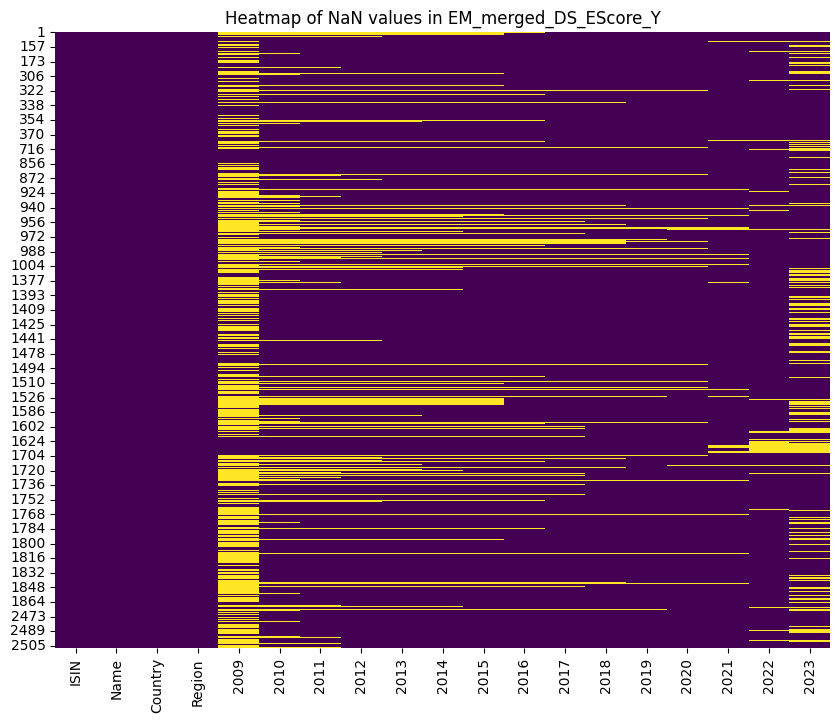

In [53]:
plt.figure(figsize=(10, 8))
sns.heatmap(EM_merged_DS_EScore_Y.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of NaN values in EM_merged_DS_EScore_Y')
plt.show()

In [54]:
# Filling in missing ESG
df_filled = EM_merged_DS_EScore_Y.copy()

# Identify the year columns (assuming they are strings representing years)
year_columns = sorted([col for col in df_filled.columns if col.isdigit()])

# Iterate through the year columns
for i in range(1, len(year_columns)):
    prev_year = year_columns[i-1]
    current_year = year_columns[i]

    # Create a mask to select rows where:
    # 1. The current year is NaN
    # 2. The previous year is NOT NaN
    # 3. The previous year's value is a float
    mask = (df_filled[current_year].isna()) & \
           (df_filled[prev_year].notna()) & \
           (df_filled[prev_year].apply(lambda x: isinstance(x, (int, float)))) #check if int or float (not only float)

    # Fill the NaN values in the current year with the previous year's float value
    df_filled.loc[mask, current_year] = df_filled.loc[mask, prev_year]

# Update DS_ESGScore_Y_filtered with the filled values
EM_merged_DS_EScore_Y = df_filled

In [55]:
#FILTERING ONLY FIRMS WITH AN E SCORE FROM 2013 ON

# Remplacer les chaînes de caractères "NaN" par np.nan
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace('NaN', np.nan)
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace(0, np.nan)

# Convert date columns to datetime if they are not already
date_columns = EM_merged_DS_EScore_Y.columns[4:]  # Assuming 'ISIN', 'Name', 'Country', 'Region' are the first 4 columns
EM_merged_DS_EScore_Y.columns = EM_merged_DS_EScore_Y.columns[:4].tolist() + pd.to_datetime(date_columns, errors='coerce').tolist()

# Select columns from 2013 onwards
start_date = pd.to_datetime('2013-12-31')
date_columns_2013_onwards = [col for col in EM_merged_DS_EScore_Y.columns
                             if isinstance(col, pd.Timestamp) and col >= start_date]

# Filter for rows with no NaN values in the selected columns
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y[
    EM_merged_DS_EScore_Y[date_columns_2013_onwards].notna().all(axis=1)
]
EM_merged_DS_EScore_Y

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


#### Restricting RI to countries with E-Score

In [56]:
isin_list = EM_merged_DS_EScore_Y['ISIN'].tolist()

# Filter EM_merged_DS_R_USD_M to keep only rows with ISINs present in the list
filtered_EM_merged_DS_RI_USD_M = EM_merged_DS_RI_USD_M[EM_merged_DS_RI_USD_M['ISIN'].isin(isin_list)].copy()
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


In [57]:
rows_with_nans = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y.isnull().any(axis=1)]
nan_counts_per_row = rows_with_nans.isnull().sum(axis=1)
df_nan_rows = pd.DataFrame({'Row': rows_with_nans.index, 'Nan_Count': nan_counts_per_row})

df_nan_rows

,Row,Nan_Count
145,145,4
151,151,1
154,154,1
155,155,1
157,157,1
...,...,...
2502,2502,1
2503,2503,3
2505,2505,1
2506,2506,1


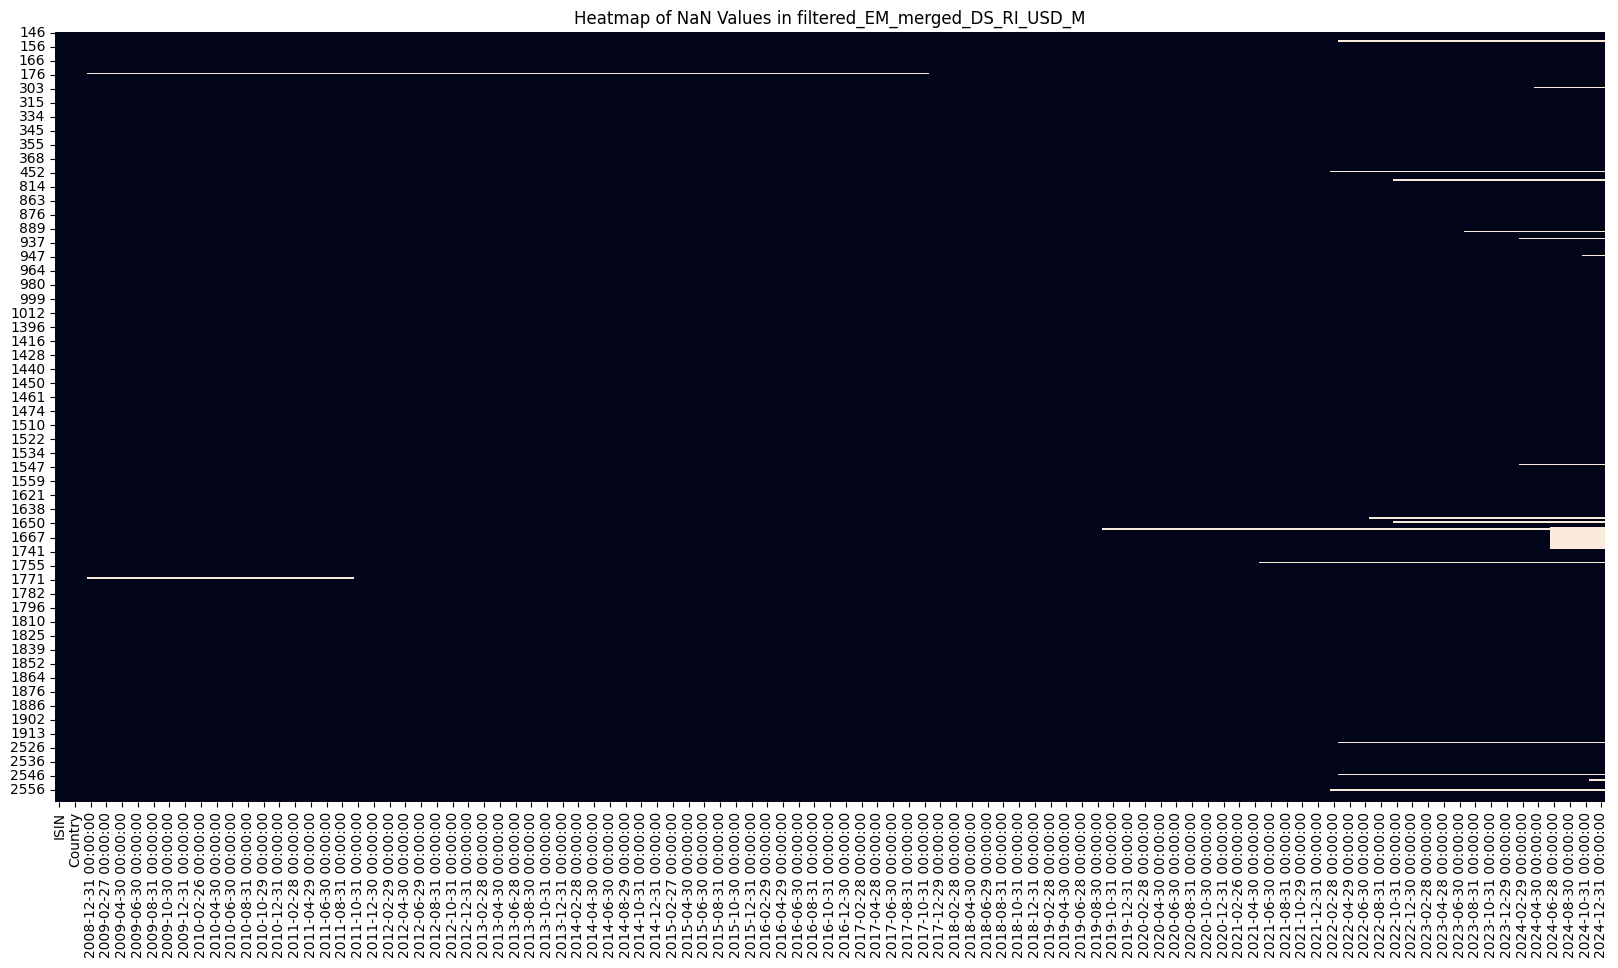

In [58]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()

#### HATZOLD RULE: NAN VALUES BETWEEN 2014 AND 2024

In [59]:
# Make a copy to preserve the original
df_filled = filtered_EM_merged_DS_RI_USD_M.copy()

# Define time series columns (numerical columns across time)
time_cols = [col for col in df_filled.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]

# Function to interpolate isolated NaNs across columns (i.e., along each row)
def interpolate_isolated_row(row):
    values = row.values.copy()
    for i in range(1, len(values) - 1):
        if pd.isna(values[i]) and not pd.isna(values[i - 1]) and not pd.isna(values[i + 1]):
            values[i] = (values[i - 1] + values[i + 1]) / 2
    return pd.Series(values, index=row.index)

# Apply row-wise interpolation only on the time columns
df_filled[time_cols] = df_filled[time_cols].apply(interpolate_isolated_row, axis=1)

# Optionally update the original DataFrame
filtered_EM_merged_DS_RI_USD_M = df_filled

In [60]:
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


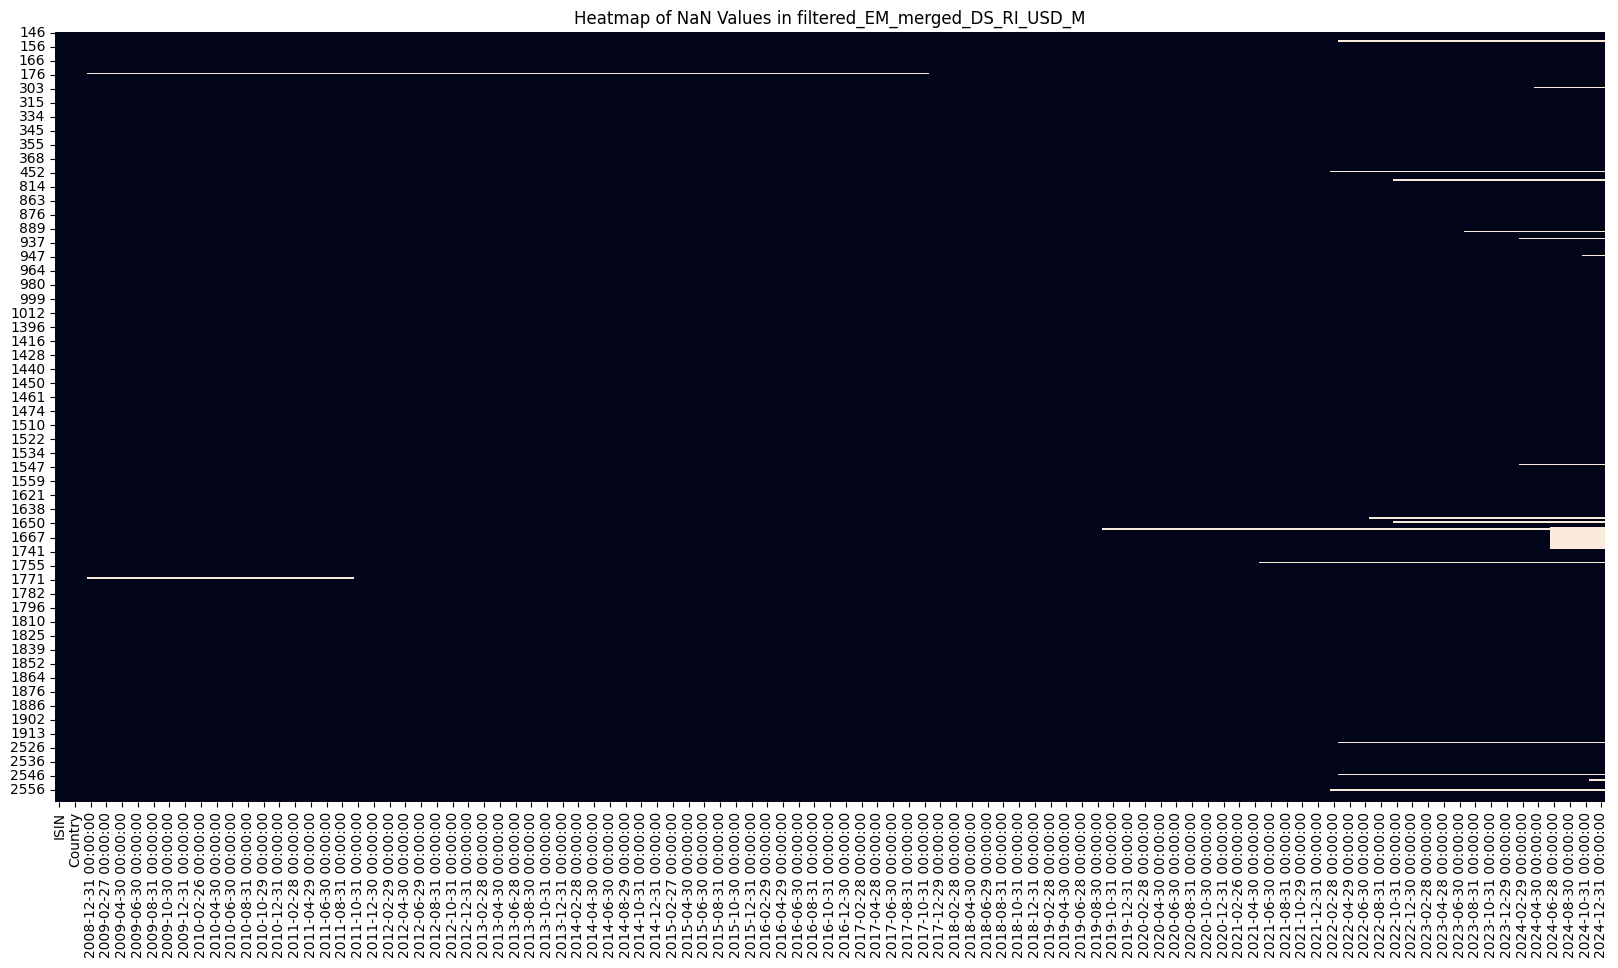

In [61]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()

In the following part, we will first try to identify which firms to get rid of because of missing values

In [62]:
# Filter for rows where 'Name' contains "SUSP" or "DELIST" and select 'Name' and 'ISIN'
filtered_name_isin = filtered_EM_merged_DS_RI_USD_M[
    filtered_EM_merged_DS_RI_USD_M['Name'].str.contains("SUSP|DELIST", case=False, na=False)
][['Name', 'ISIN']]

filtered_name_isin

,Name,ISIN
152,CMPH.ENGT.DE SAOP.B PN DEAD - DELIST.29/03/22,BRCESPACNPB4
302,AES ANDES DEAD - DELIST.18/04/24,CL0002694637
378,TELF.O2 CZECH REPUBLIC DEAD - DELIST.25/02/22,CZ0009093209
722,LAMPRELL DEAD - DELIST.25/10/22,GB00B1CL5249
934,RELIANCE CAPITAL SUSP - SUSP.29/02/24,INE013A01015
946,IDFC DEAD - DELIST.11/10/24,INE043D01016
1544,UMW HOLDINGS DEAD - DELIST.19/02/24,MYL4588OO009
1646,GRUPA LOTOS DEAD - DELIST.12/08/22,PLLOTOS00025
1649,POLISH OIL AND GAS DEAD - DELIST.18/11/22,PLPGNIG00014
1753,THAI AIRWAYS INTL. SUSP - SUSP.25/03/24,TH0245010002


In [63]:
isins_to_remove = filtered_name_isin['ISIN'].tolist()

filtered_dead_EM_merged_DS_RI_USD_M = filtered_EM_merged_DS_RI_USD_M[~filtered_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)]

filtered_dead_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


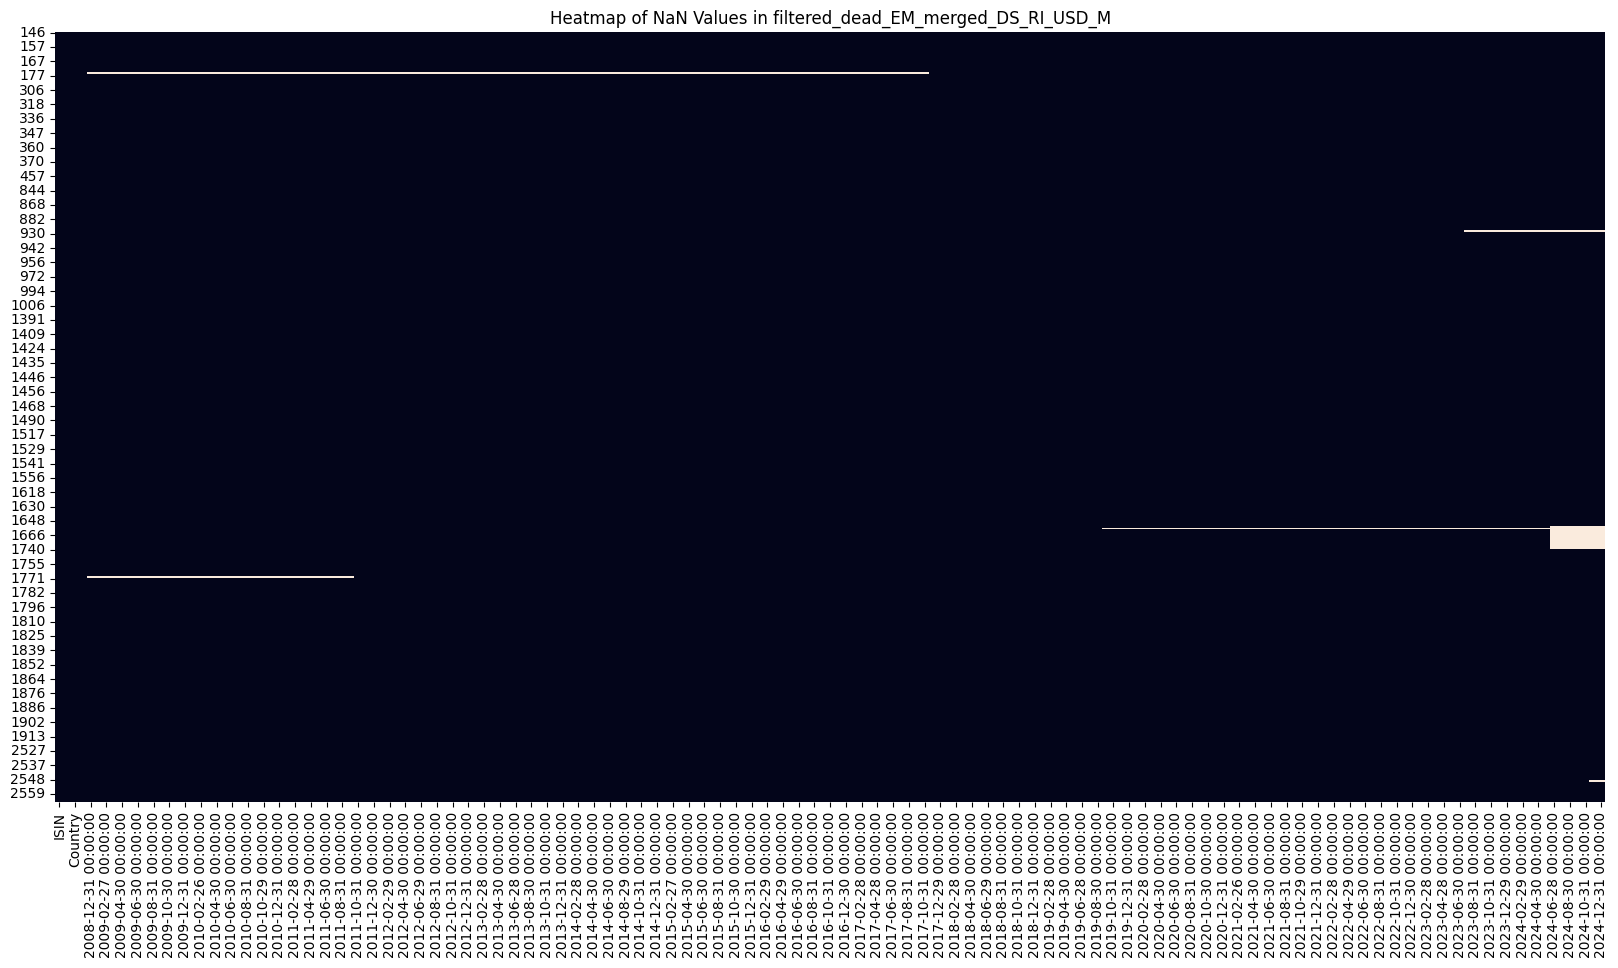

In [64]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_EM_merged_DS_RI_USD_M')
plt.show()

In [65]:
df_nan_rows = filtered_dead_EM_merged_DS_RI_USD_M[filtered_dead_EM_merged_DS_RI_USD_M.isnull().any(axis=1)][['Name', 'ISIN']]
df_nan_rows

,Name,ISIN
175,SUZANO ON,BRSUZBACNOR0
928,HOUSING DEVELOPMENT FINANCE CORPORATION,INE001A01036
1660,MMC NORILSK NICKEL,RU0007288411
1661,URALKALI,RU0007661302
1662,GAZPROM,RU0007661625
1663,ROSTELECOM,RU0008943394
1664,NK LUKOIL,RU0009024277
1665,SBERBANK OF RUSSIA,RU0009029540
1666,TATNEFT,RU0009033591
1667,SEVERSTAL,RU0009046510


In [66]:
isins_to_remove = df_nan_rows['ISIN'].tolist()

# Remove rows where ISIN is in isins_to_remove
filtered_dead_nan_EM_merged_DS_RI_USD_M = filtered_dead_EM_merged_DS_RI_USD_M[
    ~filtered_dead_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)
]

In [67]:
nan_counts = filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull().sum().sum()
print("Total number of NaN values:", nan_counts)

Total number of NaN values: 0


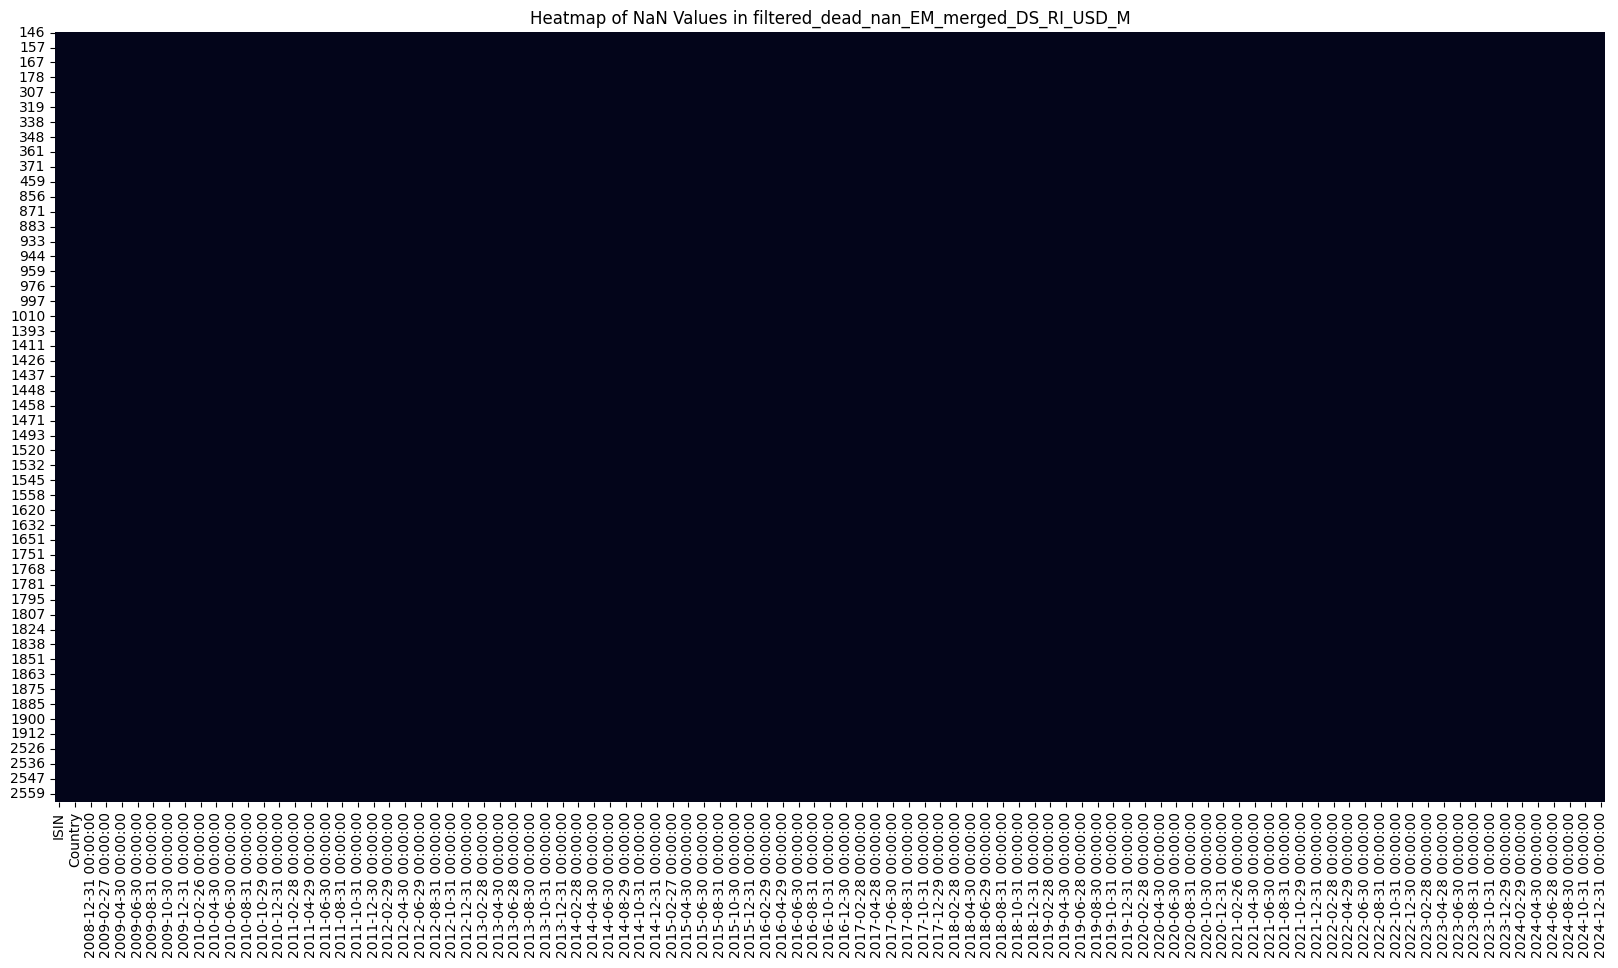

In [68]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_nan_EM_merged_DS_RI_USD_M')
plt.show()

## **Data frames**

#### Return index dataframe

In [69]:
returns = filtered_dead_nan_EM_merged_DS_RI_USD_M

#### Simple returns data frame

In [70]:
# 1. Define metadata columns
metadata_cols = ['ISIN', 'Name', 'Country', 'Region']

# 2. Separate date and metadata columns
date_cols = [col for col in returns.columns if col not in metadata_cols]

# 3. Convert date columns to numeric (coerce errors)
data = returns[date_cols].apply(pd.to_numeric, errors='coerce')

# 4. Compute simple returns using built-in pct_change
returns_pct = data.pct_change(axis=1)

# 5. Replace infinite values and fill NaNs with 0
returns_pct.replace([np.inf, -np.inf], 0, inplace=True)
returns_pct.fillna(0, inplace=True)

# 6. Combine with metadata
simple_returns = pd.concat([
    returns[metadata_cols].reset_index(drop=True),
    returns_pct.reset_index(drop=True)
], axis=1)

simple_returns

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


#### E-Score data frame

In [71]:
isin_list_R = simple_returns['ISIN'].tolist()

# Filter EM_merged_DS_EScore_Y to keep only rows with ISINs present in the list
EScore = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_R)].copy()
EScore

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


#### Simple returns no zeros

In [72]:
threshold = 0.40

def remove_rows_with_many_zeros(df, threshold):
  """Removes rows where the count of zero values exceeds the threshold."""
  rows_to_drop = []
  for index, row in df.iterrows():
    total_values = len(row)
    zero_count = (row == 0).sum()
    if total_values > 0 and (zero_count / total_values) > threshold:
      rows_to_drop.append(index)

  df_cleaned = df.drop(rows_to_drop)
  return df_cleaned

# Example usage:
simple_returns_cleaned = remove_rows_with_many_zeros(simple_returns, threshold)

# Print the cleaned DataFrame
simple_returns_no_zeros = simple_returns_cleaned

isin_list_simple_returns_cleaned = simple_returns_no_zeros['ISIN'].tolist()

In [73]:
simple_returns_no_zeros

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


In [74]:
nan_count = simple_returns_no_zeros.isnull().sum().sum()
print(f"Total number of NaN values in simple_returns_no_zeros: {nan_count}")

Total number of NaN values in simple_returns_no_zeros: 0


<ipython-input-75-40a93cce14bd>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cmap='viridis', cbar=False)


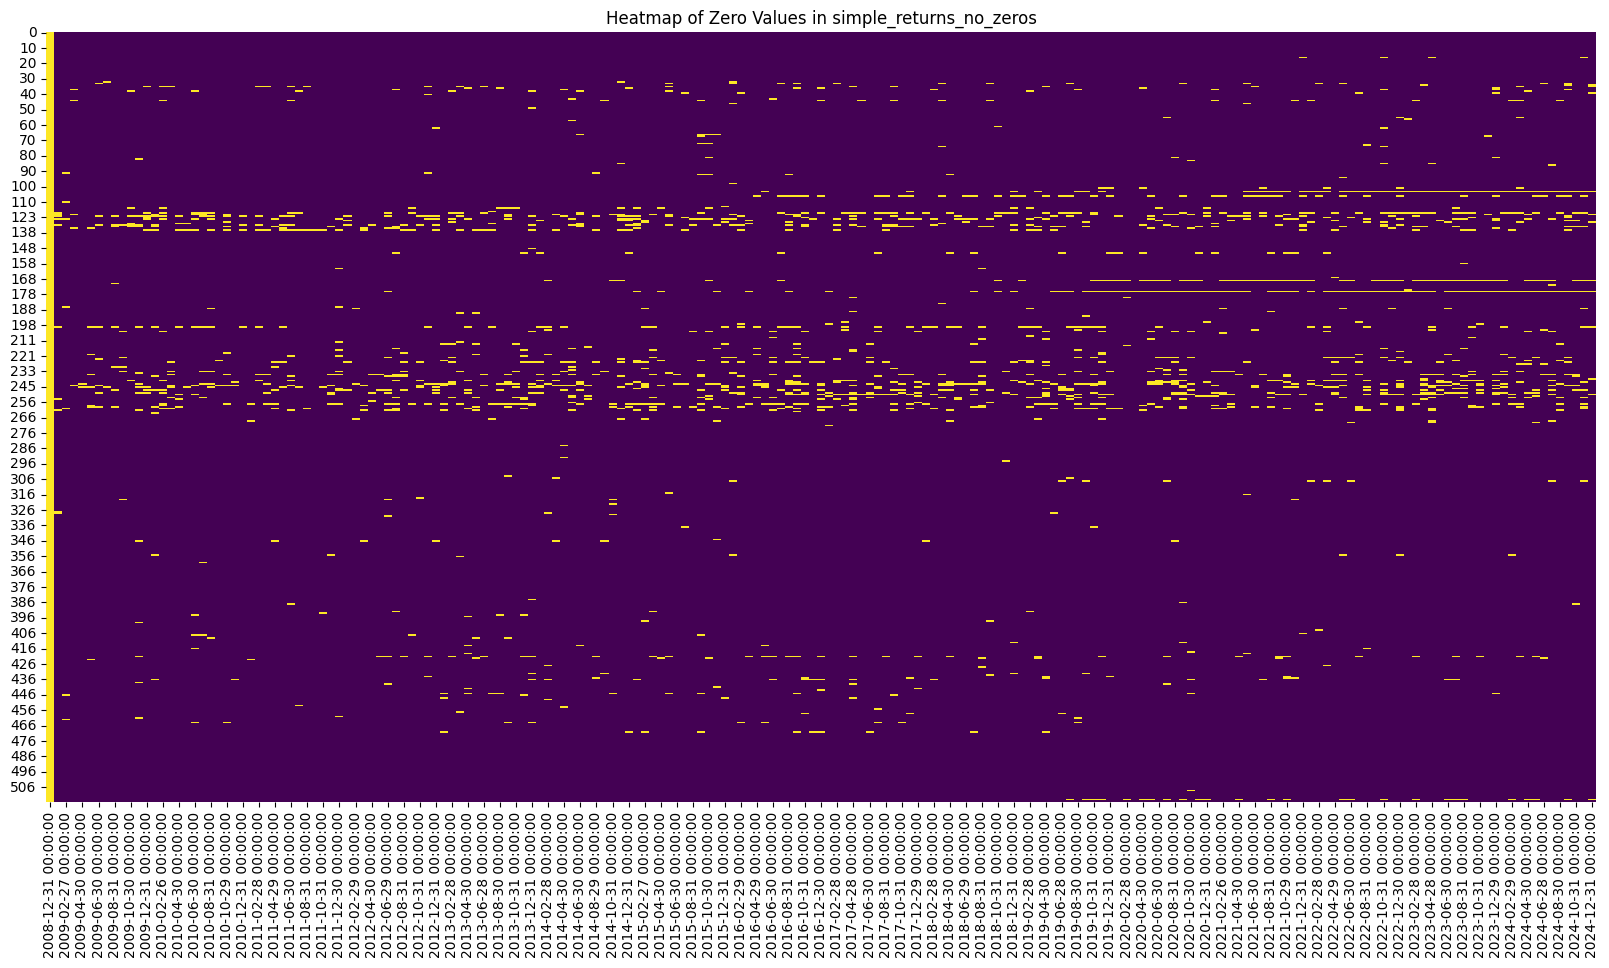

In [75]:
plt.figure(figsize=(20, 10))
sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cmap='viridis', cbar=False)
plt.title('Heatmap of Zero Values in simple_returns_no_zeros')
plt.show()

#### E-Score no zeros

In [76]:
EScore_no_zeros = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
EScore_no_zeros

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


#### Data frames restricted time frame

##### Simple returns no zeros

In [77]:
df = simple_returns_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:3]) + list(pd.to_datetime(df.columns[3:]))

start_date = pd.to_datetime('2009-01-30 00:00:00')
end_date = pd.to_datetime('2024-12-31 00:00:00')

# Select only the date range columns
simple_returns_M_2009_2024 = df.loc[:, start_date:end_date]

simple_returns_M_2009_2024

,2009-01-30,2009-02-27,2009-03-31,2009-04-30,2009-05-29,2009-06-30,2009-07-31,2009-08-31,2009-09-30,2009-10-30,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.042665,0.020508,0.139945,0.137388,0.202735,-0.015351,0.071526,0.127902,0.112810,0.082226,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
BRBBASACNOR3,-0.029038,-0.024663,0.270417,0.161538,0.267537,0.015014,0.165587,0.118995,0.260807,-0.077842,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
BRBBDCACNPR8,-0.072389,-0.023411,0.155468,0.248645,0.234734,-0.036107,0.067797,0.046571,0.205743,0.002816,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
BRBRFSACNOR8,0.080043,-0.094964,0.001767,0.190736,0.338332,-0.038486,0.152918,0.018109,0.179561,-0.076438,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
BRBRKMACNPA4,0.032655,-0.078423,-0.077588,0.361663,0.277753,0.007898,0.208685,0.263173,0.129916,0.060759,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,-0.038896,-0.182688,0.103545,0.233599,0.102493,0.190152,0.065484,0.002709,0.024090,0.047046,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
ZAE000255915,-0.220778,-0.027959,0.186990,0.148198,0.087830,0.127362,0.052348,0.105134,-0.026847,0.004522,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
ZAE000298253,-0.230407,0.267228,0.264653,0.235547,0.274169,-0.087102,0.218085,0.087063,-0.144615,0.088641,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888


##### E-Score no zeros

In [78]:
df = EScore_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:4]) + list(pd.to_datetime(df.columns[4:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2023')

# Select only the date range columns
EScore_Y_2009_2024 = df.loc[:, start_date:end_date]

EScore_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,
BRABEVACNOR1,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
BRBBASACNOR3,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
BRBBDCACNPR8,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
BRBRFSACNOR8,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
BRBRKMACNPA4,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
ZAE000255915,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
ZAE000298253,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96


## **[Homework2] Question 3: Minimum variance portfolio (40 points)**

## **REBALANCED PORTFOLIO**


In [79]:
#WIDE TO LONG FORMAT FOR OUR ESCORE DATAFRAME

# Reset the index to make 'ISIN' a regular column
EScore_Y_2009_2024 = EScore_Y_2009_2024.reset_index()

# Melt the DataFrame to long format
long_filtered_EM_merged_DS_EScore_Y = pd.melt(
    EScore_Y_2009_2024,
    id_vars=['ISIN'],  # Include all metadata columns as id_vars
    var_name='Date',
    value_name='E_Score'
)

# Convert 'Date' column to datetime
long_filtered_EM_merged_DS_EScore_Y['Date'] = pd.to_datetime(long_filtered_EM_merged_DS_EScore_Y['Date'])

# Display the long-format DataFrame
long_filtered_EM_merged_DS_EScore_Y.head()

,ISIN,Date,E_Score
0,BRABEVACNOR1,2009-01-01,NaN
1,BRBBASACNOR3,2009-01-01,68.98
2,BRBBDCACNPR8,2009-01-01,78.70
3,BRBRFSACNOR8,2009-01-01,53.61
4,BRBRKMACNPA4,2009-01-01,58.64


In [80]:
#WIDE TO LONG FORMAT FOR OUR RETURNS DATAFRAME

# Reset the index to make 'ISIN' a regular column
simple_returns_M_2009_2024 = simple_returns_M_2009_2024.reset_index()

# Melt the DataFrame to long format
long_filtered_EM_merged_DS_R_USD_M = pd.melt(
    simple_returns_M_2009_2024,
    id_vars=['ISIN'],  # Include all metadata columns as id_vars
    var_name='Date',
    value_name='Returns'
)

# Convert 'Date' column to datetime
long_filtered_EM_merged_DS_R_USD_M['Date'] = pd.to_datetime(long_filtered_EM_merged_DS_R_USD_M['Date'])

# Display the long-format DataFrame
long_filtered_EM_merged_DS_R_USD_M.head()

,ISIN,Date,Returns
0,BRABEVACNOR1,2009-01-30,-0.042665
1,BRBBASACNOR3,2009-01-30,-0.029038
2,BRBBDCACNPR8,2009-01-30,-0.072389
3,BRBRFSACNOR8,2009-01-30,0.080043
4,BRBRKMACNPA4,2009-01-30,0.032655


#### Portfolios

In [81]:
# INITIALIZATION for 2014 (2009-2013: 5 year window)

# Define the start and end dates for the 5-year window before 2014
start_date = pd.to_datetime('2014-01-01') - pd.DateOffset(years=5)
end_date = pd.to_datetime('2014-01-01')

# Filter the data for the 5-year window
filtered_data = long_filtered_EM_merged_DS_R_USD_M[
    (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
    (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
]

# Pivot the data to create a DataFrame with ISINs as columns and dates as index
cov_matrix_initial = filtered_data.pivot(index='Date', columns='ISIN', values='Returns').cov()

# Display the covariance matrix
cov_matrix_initial

ISIN,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCCROACNOR2,BRCMIGACNPR3,BRCPFEACNOR0,BRCPLEACNPB9,BRCSANACNOR6,...,ZAE000109815,ZAE000117321,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,0.005977,0.005148,0.004486,0.003444,0.005371,0.004035,0.003562,0.002656,0.004353,0.005982,...,0.003589,0.002691,0.004314,0.003370,0.003218,0.002856,0.004472,0.004561,0.004286,0.002293
BRBBASACNOR3,0.005148,0.014718,0.010100,0.006505,0.008377,0.005804,0.004328,0.003611,0.006389,0.008979,...,0.007179,0.006474,0.008357,0.005711,0.005412,0.004924,0.007335,0.008084,0.007312,0.004229
BRBBDCACNPR8,0.004486,0.010100,0.009747,0.005720,0.007206,0.005797,0.003892,0.003434,0.005575,0.008184,...,0.005113,0.004783,0.006211,0.003798,0.004311,0.004007,0.005625,0.005547,0.005980,0.003513
BRBRFSACNOR8,0.003444,0.006505,0.005720,0.008410,0.007424,0.004472,0.001718,0.002989,0.004196,0.007366,...,0.003005,0.003373,0.004353,0.003147,0.002829,0.003070,0.003683,0.003847,0.004234,0.002800
BRBRKMACNPA4,0.005371,0.008377,0.007206,0.007424,0.019113,0.007300,0.004252,0.004991,0.007985,0.012079,...,0.004388,0.004882,0.006524,0.005283,0.005474,0.005493,0.005111,0.006048,0.007333,0.004666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,0.002856,0.004924,0.004007,0.003070,0.005493,0.003851,0.002305,0.001524,0.004126,0.004094,...,0.004891,0.004219,0.003798,0.003711,0.004190,0.007349,0.004730,0.004244,0.004439,0.002830
ZAE000255915,0.004472,0.007335,0.005625,0.003683,0.005111,0.004458,0.003323,0.002642,0.004659,0.005837,...,0.007382,0.005127,0.006491,0.005497,0.005047,0.004730,0.008264,0.006826,0.006684,0.003583
ZAE000298253,0.004561,0.008084,0.005547,0.003847,0.006048,0.005042,0.003080,0.002921,0.004652,0.007778,...,0.006769,0.005475,0.005553,0.006301,0.003533,0.004244,0.006826,0.016734,0.006703,0.003491


In [82]:
# INITIALIZATION OF WEIGHTS for 2014 (2009-2013: 5 year window): just for visualization

# Objective function: portfolio variance
def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix,weights))

# Number of assets
num_assets = len(cov_matrix_initial)

# Assuming every asset have the same weights
init_guess = num_assets * [1. / num_assets]

# Constraint 1: sum of weights is 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Constraint 2: weights can only take values between 0 and 1
bounds = tuple((0, 1) for asset in range(num_assets))

# Optimization: minimize the portfolio variance
portfolio_initial = minimize(portfolio_variance, init_guess, args=(cov_matrix_initial,), method='SLSQP', bounds=bounds, constraints=constraints)

# Optimized weights
initial_weights = portfolio_initial.x

# Display the optimized weights
initial_weights

array([9.30191676e-18, 2.39406558e-18, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.58476661e-18, 0.00000000e+00,
       6.92839090e-19, 0.00000000e+00, 0.00000000e+00, 8.52949998e-18,
       0.00000000e+00, 1.58925968e-18, 1.59667827e-18, 0.00000000e+00,
       7.64585336e-18, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.48410189e-18, 9.64664876e-18, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       8.01246890e-19, 0.00000000e+00, 7.20449155e-19, 3.02283269e-18,
       0.00000000e+00, 0.00000000e+00, 1.48963856e-18, 1.17462237e-02,
       0.00000000e+00, 3.11479869e-18, 2.27654058e-19, 1.46731387e-18,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.51069809e-18,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.63814788e-18,
       0.00000000e+00, 0.00000000e+00, 1.52158045e-18, 3.18453056e-02,
       2.29760161e-18, 8.89495103e-03, 2.37803539e-18, 0.00000000e+00,
      

In [83]:
#COMPUTATION OF THE OPTIMIZED WEIGHTS

weights = []  # List to store weights for each year

for time in ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']:
    start_date = pd.to_datetime(f'{time}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{time}-01-01')
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[(long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) & (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)]
    cov_matrix = rw_timeframe.pivot(index='Date', columns='ISIN', values='Returns').cov()
    num_assets = len(cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for asset in range(num_assets))
    initial_weights = num_assets * [1. / num_assets]  # Initial weights
    portfolio = minimize(portfolio_variance, initial_weights, args=(cov_matrix,), method='SLSQP', bounds=bounds, constraints=constraints)
    weights.append(portfolio.x)  # Store the calculated weights


In [84]:
#COMPUTATION OF THE FINAL PORTFOLIO WITH E SCORE
portfolio_final_E = pd.DataFrame()

for year in [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]:
    # Get the start and end dates for the 5-year window before the current year
    start_date = pd.to_datetime(f'{year}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{year}-01-01')

    # Filter the returns data for the 5-year window (only to get ISINs)
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[
        (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
        (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
    ]

    # Get the unique ISINs from the filtered returns data
    isins = rw_timeframe['ISIN'].unique()

    # Create a DataFrame with the ISINs and their corresponding weights for the current year
    names = pd.DataFrame({'ISIN': isins})
    names['weight'] = weights[year - 2014]

    # Filter E-scores for the current year
    escore_timeframe = long_filtered_EM_merged_DS_EScore_Y[long_filtered_EM_merged_DS_EScore_Y['Date'].dt.year == year]

    # Merge weights with E-scores using ISIN
    merged = pd.merge(escore_timeframe[['ISIN', 'Date', 'E_Score']], names, on='ISIN', how='left')

    # Calculate weighted E-score
    merged['weighted_E_score'] = merged['E_Score'] * merged['weight']

    portfolio_final_E = pd.concat([portfolio_final_E, merged])

#Computation of the rebalanced portfolio (weighted average E-score per date)
rebalanced_E = portfolio_final_E.groupby('Date')['weighted_E_score'].sum().reset_index()
rebalanced_E

#portfolio_final_E: to compare with 1.2 portfolio

,Date,weighted_E_score
0,2014-01-01,56.008425
1,2015-01-01,47.541380
2,2016-01-01,56.728692
3,2017-01-01,60.468760
4,2018-01-01,65.061733
5,2019-01-01,60.999962
6,2020-01-01,62.624166
7,2021-01-01,62.479136
8,2022-01-01,65.041407
9,2023-01-01,72.953683


In [85]:
prev_weighted_E_score = rebalanced_E.copy()

In [86]:
# COMPUTATION OF THE 1.2 OPTIMIZED WEIGHTS

weights = []  # List to store weights for each year

for time in ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']:
    start_date = pd.to_datetime(f'{time}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{time}-01-01')

    # Filter data for the current time window
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[
        (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
        (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
    ]
    escore_timeframe = long_filtered_EM_merged_DS_EScore_Y[
        long_filtered_EM_merged_DS_EScore_Y['Date'].dt.year == int(time)
    ]

    # Calculate covariance matrix
    cov_matrix = rw_timeframe.pivot(index='Date', columns='ISIN', values='Returns').cov()
    num_assets = len(cov_matrix)

    # Define constraints
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

    # Get E-scores for the current year
    e_scores = escore_timeframe.set_index('ISIN')['E_Score'].to_dict()

    # Check if e_scores is empty and handle it appropriately
    if not e_scores:
        # If e_scores is empty, skip the E-score constraint for this year
        print(f"Warning: E-scores are empty for year {time}. Skipping E-score constraint.")

    else:
        # Get the previous weighted E-score for the current year
        prev_weighted_E_score_value = prev_weighted_E_score[
            prev_weighted_E_score['Date'].dt.year == int(time)
        ]['weighted_E_score'].values[0]  # Access the value for the specific year


        # Add the E-score constraint to constraints
        constraints = (
            constraints,
            {'type': 'ineq', 'fun': lambda x: np.dot(x, list(e_scores.values())) - 1.2 * prev_weighted_E_score_value}
        )
    # Define bounds
    bounds = tuple((0, 1) for asset in range(num_assets))

    # Initial weights
    initial_weights = num_assets * [1. / num_assets]

    # Optimization
    portfolio = minimize(
        portfolio_variance,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    weights.append(portfolio.x)  # Store the calculated weights

In [87]:
# VISUALIZATION OF 1.2 PORTFOLIO for all years

# Initialize an empty DataFrame to store portfolio information for all years
portfolio_final_E_constrained_all_years = pd.DataFrame()

for year in range(2014, 2024):  # Iterate through years 2014 to 2023
    # Get the start and end dates for the 5-year window before the current year
    start_date = pd.to_datetime(f'{year}-01-01') - pd.DateOffset(years=5)
    end_date = pd.to_datetime(f'{year}-01-01')

    # Filter the returns data for the 5-year window (only to get ISINs)
    rw_timeframe = long_filtered_EM_merged_DS_R_USD_M[
        (long_filtered_EM_merged_DS_R_USD_M['Date'] >= start_date) &
        (long_filtered_EM_merged_DS_R_USD_M['Date'] < end_date)
    ]

    # Get the unique ISINs from the filtered returns data
    isins = rw_timeframe['ISIN'].unique()

    # Create a DataFrame with the ISINs and their corresponding weights for the current year
    names = pd.DataFrame({'ISIN': isins})
    names['weight'] = weights[year - 2014]  # Use weights calculated previously for the current year

    # Filter E-scores for the current year
    escore_timeframe = long_filtered_EM_merged_DS_EScore_Y[long_filtered_EM_merged_DS_EScore_Y['Date'].dt.year == year]

    # Merge weights with E-scores using ISIN
    merged = pd.merge(escore_timeframe[['ISIN', 'Date', 'E_Score']], names, on='ISIN', how='left')

    # Calculate weighted E-score
    merged['weighted_E_score'] = merged['E_Score'] * merged['weight']

    # Concatenate the results to the final DataFrame
    portfolio_final_E_constrained_all_years = pd.concat([portfolio_final_E_constrained_all_years, merged])

# Create the rebalanced portfolio with constrained weights for all years
rebalanced_E_constrained_all_years = portfolio_final_E_constrained_all_years.groupby('Date')['weighted_E_score'].sum().reset_index()

# Display the rebalanced portfolio with constrained weights for all years
print(rebalanced_E_constrained_all_years)

        Date  weighted_E_score
0 2014-01-01         67.210110
1 2015-01-01         57.049656
2 2016-01-01         68.074430
3 2017-01-01         72.562512
4 2018-01-01         78.074080
5 2019-01-01         73.199955
6 2020-01-01         75.148999
7 2021-01-01         74.974963
8 2022-01-01         78.049688
9 2023-01-01         87.544419


In [88]:
portfolio_final_E_constrained_all_years

,ISIN,Date,E_Score,weight,weighted_E_score
0,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00
1,BRBBASACNOR3,2014-01-01,90.21,2.149085e-18,1.938690e-16
2,BRBBDCACNPR8,2014-01-01,83.16,1.013173e-17,8.425547e-16
3,BRBRFSACNOR8,2014-01-01,78.70,3.629253e-18,2.856222e-16
4,BRBRKMACNPA4,2014-01-01,41.05,0.000000e+00,0.000000e+00
...,...,...,...,...,...
495,ZAE000191342,2023-01-01,37.06,0.000000e+00,0.000000e+00
496,ZAE000255915,2023-01-01,84.75,0.000000e+00,0.000000e+00
497,ZAE000298253,2023-01-01,63.96,0.000000e+00,0.000000e+00
498,ZAE000302618,2023-01-01,25.61,0.000000e+00,0.000000e+00


#### Portfolios analysis

In [89]:
#COMPARISON OF ESCORES

# Rename the 'weighted_E_score' column in 'rebalanced_E_constrained_all_years'
rebalanced_E_constrained_all_years = rebalanced_E_constrained_all_years.rename(
    columns={'weighted_E_score': 'weighted_E_score_constrained'}
)

# Merge the two DataFrames based on 'Date'
merged_df = pd.merge(rebalanced_E, rebalanced_E_constrained_all_years, on='Date', how='left')

# Extract the year from the 'Date' column and create a new 'Year' column
merged_df['Year'] = merged_df['Date'].dt.year

# Group by 'Year' and calculate the average weighted E-scores for both portfolios
final_df = merged_df.groupby('Year')[
    ['weighted_E_score', 'weighted_E_score_constrained']
].mean().reset_index()

# Display the final DataFrame
print(final_df)

   Year  weighted_E_score  weighted_E_score_constrained
0  2014         56.008425                     67.210110
1  2015         47.541380                     57.049656
2  2016         56.728692                     68.074430
3  2017         60.468760                     72.562512
4  2018         65.061733                     78.074080
5  2019         60.999962                     73.199955
6  2020         62.624166                     75.148999
7  2021         62.479136                     74.974963
8  2022         65.041407                     78.049688
9  2023         72.953683                     87.544419


In [94]:
portfolio_final_E['Year'] = portfolio_final_E['Date'].dt.year
portfolio_final_E['Month'] = portfolio_final_E['Date'].dt.month

portfolio_final_E_constrained_all_years['Year'] = portfolio_final_E_constrained_all_years['Date'].dt.year
portfolio_final_E_constrained_all_years['Month'] = portfolio_final_E_constrained_all_years['Date'].dt.month

In [96]:
# CHANGES THAT WERE NECESSARY?

# 1. Average weighted E-scores in 2023
benchmark_e_score_2023 = portfolio_final_E[portfolio_final_E['Year'] == 2023]['weighted_E_score'].mean()
constrained_e_score_2023 = portfolio_final_E_constrained_all_years[portfolio_final_E_constrained_all_years['Year'] == 2023]['weighted_E_score'].mean()

# 2. Firms with low E-scores in 2023
low_e_score_firms = portfolio_final_E[portfolio_final_E['Year'] == 2023].sort_values('E_Score').head(n=10)  # Adjust 'n' for the number of firms to examine

# 3. Excluded firms (Firms with weight 0 in 2023)
excluded_firms_isins = portfolio_final_E_constrained_all_years[
    (portfolio_final_E_constrained_all_years['Year'] == 2023) & (portfolio_final_E_constrained_all_years['weight'] == 0)
]['ISIN'].unique().tolist() # Get unique ISINs of excluded firms

# 4. Retrieve names of excluded firms using ISINs from EScore_no_zeros
excluded_firms_names = EScore_no_zeros[EScore_no_zeros['ISIN'].isin(excluded_firms_isins)]['Name'].tolist()

# 5. Number and names of excluded firms
num_excluded_firms = len(excluded_firms_isins)

print(f"Number of excluded firms in 2023: {num_excluded_firms}")
print(f"ISINs of excluded firms: {excluded_firms_isins}")
print(f"Names of excluded firms: {excluded_firms_names}")

Number of excluded firms in 2023: 261
ISINs of excluded firms: ['BRBBASACNOR3', 'BRBBDCACNPR8', 'BRBRFSACNOR8', 'BRBRKMACNPA4', 'BRCCROACNOR2', 'BRCPLEACNPB9', 'BRCSANACNOR6', 'BREGIEACNOR9', 'BRELETACNPB7', 'BREMBRACNOR4', 'BRGFSAACNOR3', 'BRGGBRACNPR8', 'BRGOAUACNPR8', 'BRITSAACNPR7', 'BRITUBACNPR1', 'BRKLBNACNPR9', 'BRPETRACNPR6', 'BRVALEACNOR0', 'CL0000000035', 'CL0000000100', 'CL0000000423', 'CL0002841873', 'CLP1506A1070', 'CLP256251073', 'CLP321331116', 'CLP3710M1090', 'CNE0000000T2', 'CNE000000SK7', 'CNE000001B33', 'CNE1000001Q4', 'CNE1000001V4', 'CNE1000001W2', 'CNE1000001Z5', 'CNE100000205', 'CNE100000221', 'CNE100000296', 'CNE1000002F5', 'CNE1000002L3', 'CNE1000002N9', 'CNE1000002T6', 'CNE1000002V2', 'CNE100000304', 'CNE1000003K3', 'CNE1000003W8', 'CNE100000437', 'CNE1000004K1', 'CNE1000004L9', 'CNE1000004Q8', 'CNE1000006Z4', 'CZ0005112300', 'EGS60121C018', 'GRS014003032', 'GRS260333000', 'GRS298343005', 'GRS323003012', 'GRS434003000', 'HK0267001375', 'HK0883013259', 'HU00000

In [97]:
# CHANGES THAT WERE NECESSARY? Linne Version

# 1. Average weighted E-scores in 2023
benchmark_e_score_2023 = portfolio_final_E[portfolio_final_E['Year'] == 2023]['weighted_E_score'].mean()
constrained_e_score_2023 = portfolio_final_E_constrained_all_years[portfolio_final_E_constrained_all_years['Year'] == 2023]['weighted_E_score'].mean()

# 2. Firms with low E-scores in 2023
low_e_score_firms = portfolio_final_E[portfolio_final_E['Year'] == 2023].sort_values('E_Score').head(n=10)  # Adjust 'n' for the number of firms to examine

# 3. Excluded firms (Firms with weight 0 in 2023)
# 3.1 excluded firms in benchmark portfolio
excluded_firms_isins_bench = portfolio_final_E[
    (portfolio_final_E['Year'] == 2023) & (portfolio_final_E['weight'] == 0)
]['ISIN'].unique().tolist()

# 3.2 Excluded firms in constrained portfolio
excluded_firms_isins_constr = portfolio_final_E_constrained_all_years[
    (portfolio_final_E_constrained_all_years['Year'] == 2023) & (portfolio_final_E_constrained_all_years['weight'] == 0)
]['ISIN'].unique().tolist() # Get unique ISINs of excluded firms

# 4. Retrieve names of excluded firms using ISINs from EScore_no_zeros
excluded_firms_names_bench = EScore_no_zeros[EScore_no_zeros['ISIN'].isin(excluded_firms_isins_bench)]['Name'].tolist()
excluded_firms_names_constr = EScore_no_zeros[EScore_no_zeros['ISIN'].isin(excluded_firms_isins_constr)]['Name'].tolist()

# 5. Number and names of excluded firms
num_excluded_firms_bench = len(excluded_firms_isins_bench)
num_excluded_firms_constr = len(excluded_firms_isins_constr)

print(f"Number of excluded firms in benchmark portfolio 2023: {num_excluded_firms_bench}")
print(f"Number of excluded firms in constrained portfolio 2023: {num_excluded_firms_constr}")

print(f"ISINs of excluded firms in benchmark portfolio : {excluded_firms_isins_bench}")
print(f"ISINs of excluded firms in constrained portfolio: {excluded_firms_isins_constr}")

print(f"Names of excluded firms in benchmark portfolio: {excluded_firms_names_bench}")
print(f"Names of excluded firms in constrained portfolio: {excluded_firms_names_constr}")

Number of excluded firms in benchmark portfolio 2023: 233
Number of excluded firms in constrained portfolio 2023: 261
ISINs of excluded firms in benchmark portfolio : ['BRABEVACNOR1', 'BRBRFSACNOR8', 'BRCCROACNOR2', 'BRCMIGACNPR3', 'BRCSNAACNOR6', 'BREGIEACNOR9', 'BRGFSAACNOR3', 'BRGGBRACNPR8', 'BRKLBNACNPR9', 'BRLIGTACNOR2', 'BRRENTACNOR4', 'BRSBSPACNOR5', 'BRUSIMACNPA6', 'CL0000001314', 'CL0002841873', 'CLP249051044', 'CLP321331116', 'CLP3615W1037', 'CLP3697S1034', 'CLP3710M1090', 'CLP371861061', 'CLP9796J1008', 'CNE0000000T2', 'CNE000001B33', 'CNE1000001Z5', 'CNE100000221', 'CNE1000002J7', 'CNE1000002L3', 'CNE1000002N9', 'CNE1000002Q2', 'CNE100000304', 'CNE100000312', 'CNE1000003G1', 'CNE100000502', 'CNE100000536', 'CZ0005112300', 'EGS3G0Z1C014', 'EGS69101C011', 'GRS260333000', 'GRS419003009', 'GRS434003000', 'HK0267001375', 'HK0883013259', 'HU0000061726', 'HU0000153937', 'ID1000066004', 'ID1000094006', 'ID1000106602', 'INE002A01018', 'INE012A01025', 'INE019A01038', 'INE036A01016', 

In [98]:
# Find firms that are in excluded_firms_names_bench but not in excluded_firms_names_constr
firms_only_in_bench = set(excluded_firms_names_bench) - set(excluded_firms_names_constr)

# Create a table with the firms that are only in the benchmark portfolio
table_firms_only_in_bench = pd.DataFrame({'Firms Only in Benchmark': list(firms_only_in_bench)})

# Print the table
table_firms_only_in_bench


,Firms Only in Benchmark
0,LS
1,NETCARE
2,HYUNDAI MOTOR
3,PIXART IMAGING
4,IJM CORPORATION
...,...
103,COLBUN MACHICURA
104,GOLD FIELDS
105,BANK OF AYUDHYA
106,CHINA MOTOR


In [99]:
# Find firms that are only in excluded_firms_names_constr but not in excluded_firms_names_bench
firms_only_in_constr = set(excluded_firms_names_constr) - set(excluded_firms_names_bench)

# Create a table with the firms that are only in the constrained portfolio
table_firms_only_in_constr = pd.DataFrame({'Firms Only in Constrained': list(firms_only_in_constr)})

# Print the table
table_firms_only_in_constr


,Firms Only in Constrained
0,HONG LEONG FINL.GP.
1,INNER MONGOLIA YITAI COAL 'B'
2,ALLIANCE GLOBAL GP.
3,LATAM AIRLINES GROUP
4,EMBRAER ON
...,...
131,DONGKUK HOLDINGS
132,JIANGXI COPPER 'H'
133,COWAY
134,TELEKOM MALAYSIA


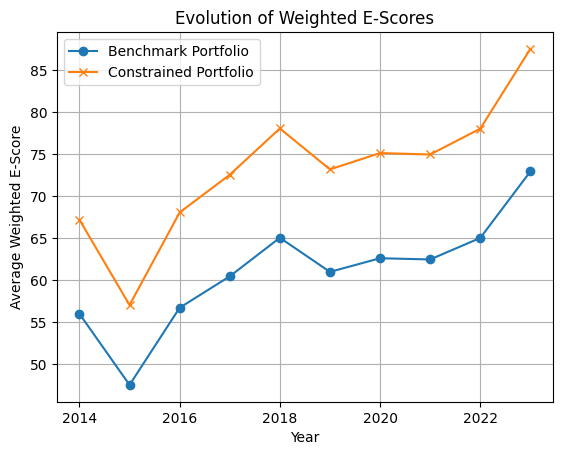

In [100]:
#PORTFOLIOS PERFORMANCE VISUALISATION

# Plot the data
plt.plot(final_df['Year'], final_df['weighted_E_score'], label='Benchmark Portfolio', marker='o')
plt.plot(final_df['Year'], final_df['weighted_E_score_constrained'], label='Constrained Portfolio', marker='x')

# Customize the plot
plt.title('Evolution of Weighted E-Scores')
plt.xlabel('Year')
plt.ylabel('Average Weighted E-Score')
plt.legend()  # Show legend
plt.grid(True)  # Add gridlines (optional)

# Display the plot
plt.show()

In [101]:
#CUMULATIVE RETURNS FOR MIN VAR PORTFOLIO

# Créer des colonnes pour le mois et l'année dans long_filtered_EM_merged_DS_R_USD_M
long_filtered_EM_merged_DS_R_USD_M['Year'] = long_filtered_EM_merged_DS_R_USD_M['Date'].dt.year
long_filtered_EM_merged_DS_R_USD_M['Month'] = long_filtered_EM_merged_DS_R_USD_M['Date'].dt.month

# Fusionner les DataFrames sur ISIN, Year et Month
cumulative_R_minvar = pd.merge(portfolio_final_E, long_filtered_EM_merged_DS_R_USD_M, on=['ISIN', 'Year', 'Month'], how='left')

# Calculer les rendements pondérés
cumulative_R_minvar['weighted_returns'] = cumulative_R_minvar['weight'] * cumulative_R_minvar['Returns']

# Afficher le DataFrame résultant
cumulative_R_minvar

,ISIN,Date_x,E_Score,weight,weighted_E_score,Year,Month,Date_y,Returns,weighted_returns
0,BRABEVACNOR1,2014-01-01,58.81,9.301917e-18,5.470457e-16,2014,1,2014-01-31,-0.081488,-7.579968e-19
1,BRBBASACNOR3,2014-01-01,90.21,2.394066e-18,2.159687e-16,2014,1,2014-01-31,-0.165964,-3.973293e-19
2,BRBBDCACNPR8,2014-01-01,83.16,0.000000e+00,0.000000e+00,2014,1,2014-01-31,-0.121563,-0.000000e+00
3,BRBRFSACNOR8,2014-01-01,78.70,0.000000e+00,0.000000e+00,2014,1,2014-01-31,-0.137319,-0.000000e+00
4,BRBRKMACNPA4,2014-01-01,41.05,0.000000e+00,0.000000e+00,2014,1,2014-01-31,-0.138089,-0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
4995,ZAE000191342,2023-01-01,37.06,8.314012e-19,3.081173e-17,2023,1,2023-01-31,-0.078724,-6.545112e-20
4996,ZAE000255915,2023-01-01,84.75,0.000000e+00,0.000000e+00,2023,1,2023-01-31,0.001249,0.000000e+00
4997,ZAE000298253,2023-01-01,63.96,1.443793e-18,9.234502e-17,2023,1,2023-01-31,-0.109795,-1.585206e-19
4998,ZAE000302618,2023-01-01,25.61,0.000000e+00,0.000000e+00,2023,1,2023-01-31,-0.071429,-0.000000e+00


In [102]:
#CUMULATIVE RETURNS FOR 20%PORTFOLIO

# Créer des colonnes pour le mois et l'année dans portfolio_final_E_constrained_all_years
portfolio_final_E_constrained_all_years['Year'] = portfolio_final_E_constrained_all_years['Date'].dt.year
portfolio_final_E_constrained_all_years['Month'] = portfolio_final_E_constrained_all_years['Date'].dt.month

# Fusionner les DataFrames sur ISIN, Year et Month
cumulative_R_20 = pd.merge(portfolio_final_E_constrained_all_years, long_filtered_EM_merged_DS_R_USD_M, on=['Year', 'Month'], how='left') #Attention: pas ISIN ici

# Reset index to bring 'ISIN' back as a regular column (if needed):
cumulative_R_20 = cumulative_R_20.reset_index()

# Calculer les rendements pondérés (cette partie peut nécessiter des ajustements en fonction de la colonne contenant les poids)
cumulative_R_20['weighted_returns'] = cumulative_R_20['weight'] * cumulative_R_20['Returns']

# Afficher le DataFrame résultant
cumulative_R_20

,index,ISIN_x,Date_x,E_Score,weight,weighted_E_score,Year,Month,ISIN_y,Date_y,Returns,weighted_returns
0,0,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00,2014,1,BRABEVACNOR1,2014-01-31,-0.081488,-0.000000e+00
1,1,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00,2014,1,BRBBASACNOR3,2014-01-31,-0.165964,-0.000000e+00
2,2,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00,2014,1,BRBBDCACNPR8,2014-01-31,-0.121563,-0.000000e+00
3,3,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00,2014,1,BRBRFSACNOR8,2014-01-31,-0.137319,-0.000000e+00
4,4,BRABEVACNOR1,2014-01-01,58.81,0.000000e+00,0.000000e+00,2014,1,BRBRKMACNPA4,2014-01-31,-0.138089,-0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...
2499995,2499995,ZAE000322095,2023-01-01,28.72,1.265054e-17,3.633234e-16,2023,1,ZAE000191342,2023-01-31,-0.078724,-9.958991e-19
2499996,2499996,ZAE000322095,2023-01-01,28.72,1.265054e-17,3.633234e-16,2023,1,ZAE000255915,2023-01-31,0.001249,1.580314e-20
2499997,2499997,ZAE000322095,2023-01-01,28.72,1.265054e-17,3.633234e-16,2023,1,ZAE000298253,2023-01-31,-0.109795,-1.388960e-18
2499998,2499998,ZAE000322095,2023-01-01,28.72,1.265054e-17,3.633234e-16,2023,1,ZAE000302618,2023-01-31,-0.071429,-9.036097e-19


In [112]:
#PLOTTING CUMULATIVE RETURNS

minvar_annual_returns = {}  # Annual returns for cumulative_R_minvar (benchmark)
constrained_annual_returns = {}  # Annual returns for cumulative_R_20 (optimized)

for year in range(2014, 2024):  # Iterate through the years
    # Get returns for the current year
    minvar_returns_year = cumulative_R_minvar[cumulative_R_minvar['Year'] == year]['weighted_returns']
    constrained_returns_year = cumulative_R_20[cumulative_R_20['Year'] == year]['weighted_returns']

    # Calculate and store annual returns
    minvar_annual_returns[year] = minvar_returns_year.mean()*12 # Additive version
    constrained_annual_returns[year] = constrained_returns_year.mean()*12  # Additive version
    # Or, for compounded version:
    #minvar_annual_returns[year] = (minvar_returns_year + 1).prod() - 1
    #constrained_annual_returns[year] = (constrained_returns_year + 1).prod() - 1

# Create a DataFrame for plotting or further analysis:
annual_returns_df = pd.DataFrame({
    'Year': list(minvar_annual_returns.keys()),
    'Min Var Annual Returns': list(minvar_annual_returns.values()),
    'Constrained Annual Returns': list(constrained_annual_returns.values())
})

# Display the annual returns:
print(annual_returns_df)

   Year  Min Var Annual Returns  Constrained Annual Returns
0  2014               -0.000836                   -0.001305
1  2015                0.000547                    0.000200
2  2016               -0.000496                   -0.001192
3  2017                0.000391                    0.001644
4  2018                0.000720                    0.001809
5  2019                0.001227                    0.001691
6  2020               -0.001114                   -0.001455
7  2021               -0.000834                   -0.000366
8  2022               -0.000175                    0.000040
9  2023                0.000493                    0.001351


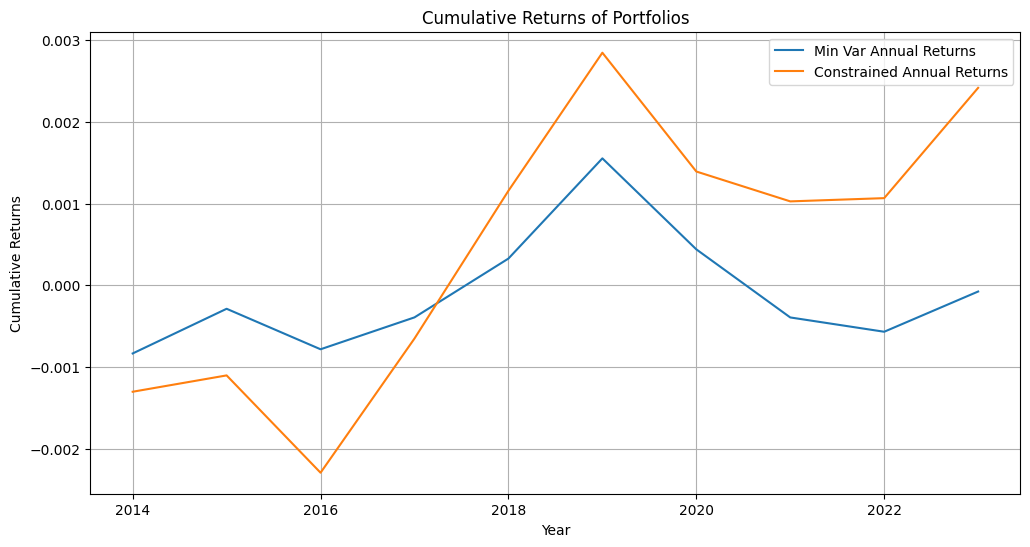

In [113]:
# prompt: for annual_returns_df make cummulative returns line graph for each column

import matplotlib.pyplot as plt
# Assuming annual_returns_df is already created as shown in the provided code
plt.figure(figsize=(12, 6))

for column in annual_returns_df.columns:
    if column != 'Year':
        plt.plot(annual_returns_df['Year'], annual_returns_df[column].cumsum(), label=column)

plt.title('Cumulative Returns of Portfolios')
plt.xlabel('Year')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()
